In [4]:
from pathlib import Path
import pickle
import itertools
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Unbiased vs biased pf:

In [ ]:
original_sub_id = 3
trial_id = 1    

unbiased_pf = pd.read_csv("data/game_data/pf_block_2_trial_1_2005.csv").to_numpy()
biased_pf = pd.read_csv(f"data/results/sub_{original_sub_id}/block_2/trial_1/submission_1/pf.csv").to_numpy()

with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_block_2_trial_{trial_id}.json") as file:
    data = json.load(file)
    
df = pd.json_normalize(
    data,
    record_path="submissions",
    meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
)
info = pd.DataFrame({
    "trial_id": df["trial_id"],
    "submission_number": df["submission_number"],
    "slider_values": df["slider_values"],
    "server_result.rec": df["server_result.rec"]
})

aspi = np.asarray(info.loc[0, "slider_values"])
query_pt = np.asarray(info.loc[0, "server_result.rec"])

In [ ]:
import math

n_obj = 5
objective_names = ["obj0", "obj1", "obj2", "obj3", "obj4"]

objective_pairs = list(itertools.combinations(range(n_obj), 2))
n_plots = len(objective_pairs)
cols = min(5, n_plots)
rows = math.ceil(n_plots / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes = np.atleast_1d(axes).ravel()
for ax, (a, b) in zip(axes, objective_pairs):
    ax.plot(unbiased_pf[:, a], unbiased_pf[:, b], "go", alpha=0.2, markersize=3, label="PF")
    ax.plot(biased_pf[:, a], biased_pf[:, b], "bo", alpha=0.2, markersize=3, label="PF")
    # sns.kdeplot(
    #     x=pf_actual_norm[:, a],
    #     y=pf_actual_norm[:, b],
    #     levels=10,
    #     fill=True,   
    #     color="green",
    #     ax=ax
    # )
    # sns.kdeplot(
    #     x=pf_norm[:, a],
    #     y=pf_norm[:, b],
    #     levels=10,
    #     fill=True,   
    #     color="steelblue",
    #     alpha=0.4,
    #     ax=ax
    # )
    ax.plot(
        aspi[a], aspi[b],
        "rs", alpha=1, markersize=6, label="Aspiration"
    )
    ax.plot(
        query_pt[a], query_pt[b],
        "ks", alpha=1, markersize=6, label="Query"
    )
    ax.set_xlabel(objective_names[a])
    ax.set_ylabel(objective_names[b])
    # ax.set_xlim(40, 140)
    # ax.set_ylim(40, 140)

for ax in axes[n_plots:]:
    ax.set_visible(False)

fig.tight_layout()
plt.show()

Distance to aspiration distributions

In [1]:
import ast
from scipy.stats import mode

In [ ]:
sub_id = 1
num_trials = 17

converters = {
    "initial_slider_values": ast.literal_eval,
    "slider_values": ast.literal_eval,
    "rec_values": ast.literal_eval,
}
all_info_nonshifted = pd.read_csv("data/all_info_10_nonshifted.csv", converters=converters)
original_sub_id = all_info_nonshifted.loc[
        (all_info_nonshifted["sub_id"] == sub_id)
    ]["original_sub_id"].iloc[0]
print(original_sub_id)

distances_unbiased = []
distances_biased = []
for trial_id in range(1, num_trials + 1):
    files = list(Path("data/game_data").glob(
        f"pf_block_2_trial_{trial_id}_*.csv"
    ))
    if len(files) != 1:
        raise ValueError(f"Expected one matching file, found {len(files)}")
    unbiased_pf = pd.read_csv(files[0]).to_numpy()

    # determine the last submission
    last_submission = all_info_nonshifted.loc[
        (all_info_nonshifted["sub_id"] == sub_id) &
        (all_info_nonshifted["trial_id"] == trial_id)
    ]["submission_number"].max()

    biased_pf = pd.read_csv(f"data/results/sub_{original_sub_id}/block_2/trial_{trial_id}/submission_{last_submission}/pf.csv").to_numpy()

    aspiration = all_info_nonshifted.loc[
        (all_info_nonshifted["sub_id"] == sub_id) &
        (all_info_nonshifted["trial_id"] == trial_id) &
        (all_info_nonshifted["submission_number"] == last_submission)
    ]["slider_values"]
    aspiration = np.asarray(aspiration.iloc[0], dtype=float)
    
    # query_pt = all_info_nonshifted.loc[
    #     (all_info_nonshifted["sub_id"] == sub_id) &
    #     (all_info_nonshifted["trial_id"] == trial_id) &
    #     (all_info_nonshifted["submission_number"] == last_submission)
    # ]["rec_values"]
    # query_pt = np.asarray(query_pt.iloc[0], dtype=float)

    print("unbiased pf shape ", unbiased_pf.shape)
    print("biased pf shape ", biased_pf.shape)
    distances_to_unbiased = np.linalg.norm(unbiased_pf - aspiration, axis=1)
    distances_to_biased = np.linalg.norm(biased_pf - aspiration, axis=1)
    print("distances to unbiased shape ", distances_to_unbiased.shape)
    print("distances to biased shape ", distances_to_biased.shape)
    distances_unbiased.append(distances_to_unbiased)
    distances_biased.append(distances_to_biased)

distances_unbiased = np.concatenate(distances_unbiased)
distances_biased = np.concatenate(distances_biased)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(distances_unbiased, bins=1000, alpha=0.5, label="Unbiased")
# ax.vlines(np.median(distances_unbiased), 0, 450, color="blue", label="Unbiased median")
ax.hist(distances_biased, bins=1000, alpha=0.5, label="Biased")
# ax.vlines(np.median(distances_biased), 0, 450, color="orange", label="Biased median")
ax.set_ylim(0, 450)
ax.set_xlabel("Distances to aspiration")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()

     sub_id  original_sub_id
0         0                2
84        1                3
121       2                4
173       3                5
236       4                6
300       5                8
369       6                9
447       7               10
517       8               11
572       9               12


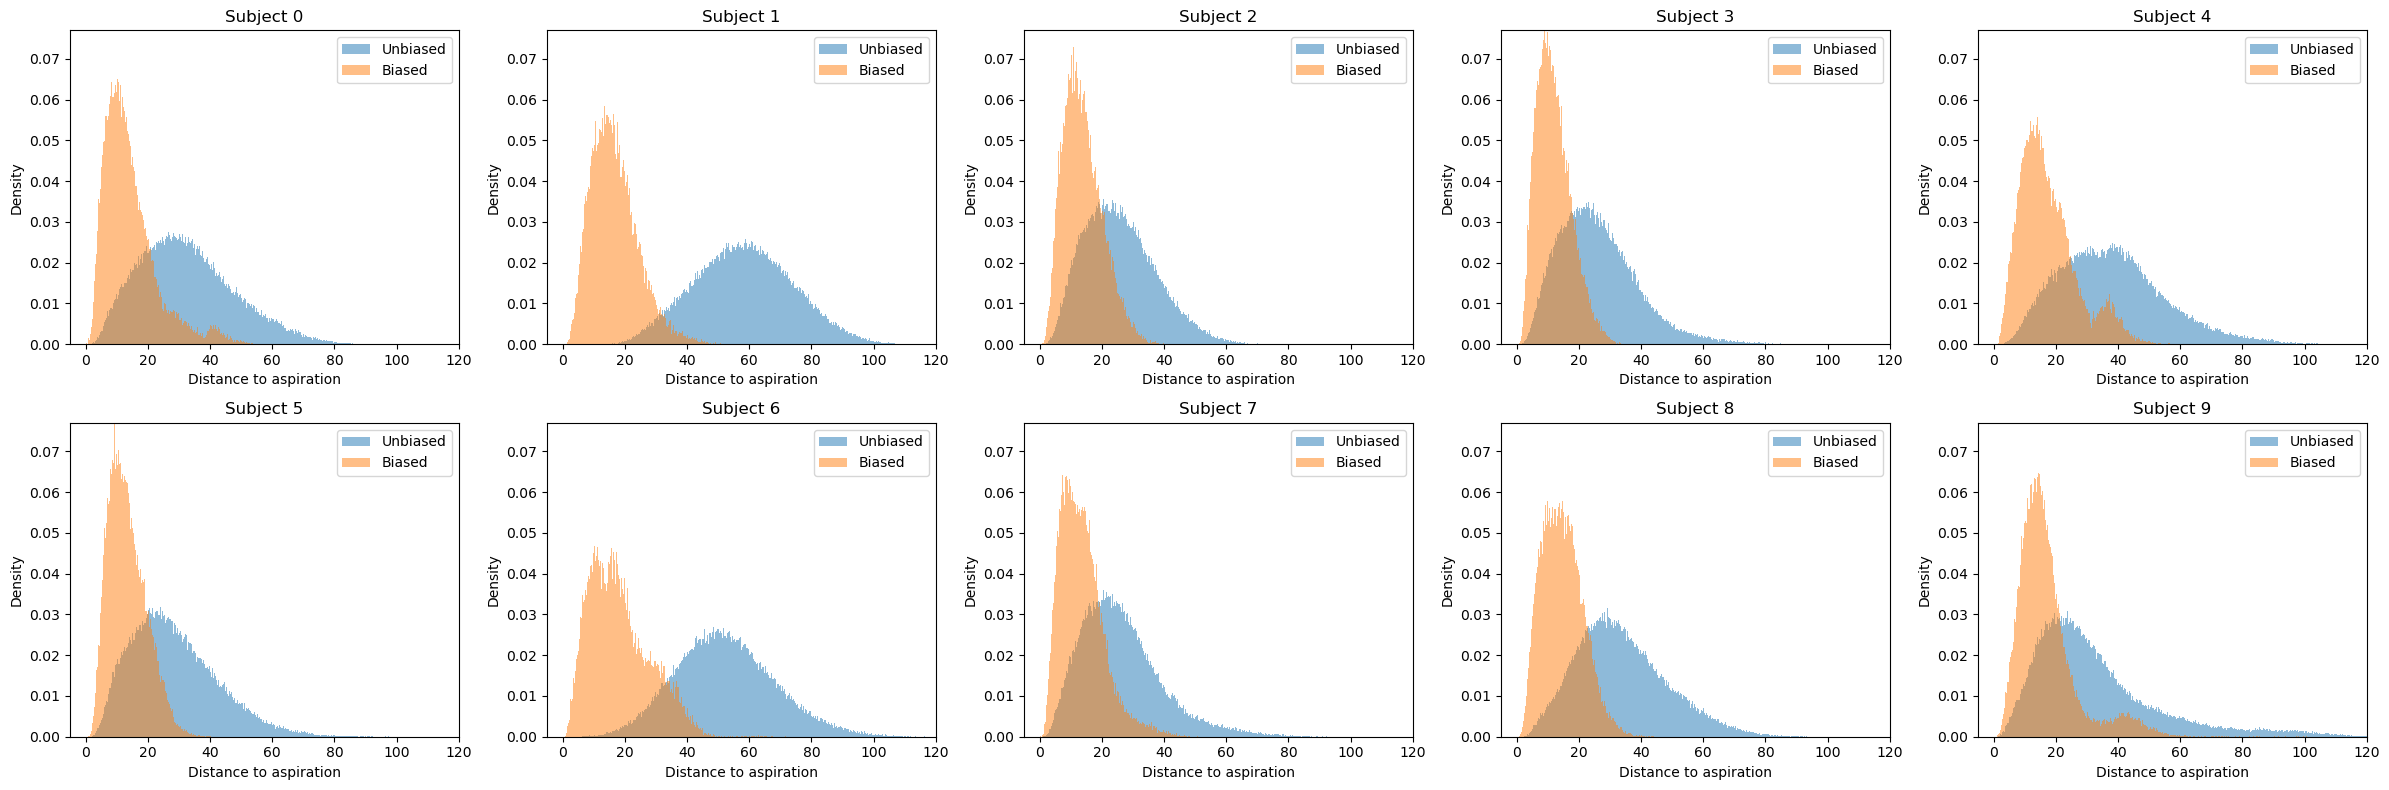

In [8]:
num_trials = 17
converters = {
    "initial_slider_values": ast.literal_eval,
    "slider_values": ast.literal_eval,
    "rec_values": ast.literal_eval,
}
all_info_nonshifted = pd.read_csv("data/all_info_10_nonshifted.csv", converters=converters)

subject_mapping = (
    all_info_nonshifted[["sub_id", "original_sub_id"]]
    .drop_duplicates()
    .sort_values("sub_id")
)
print(subject_mapping)

fig, axes = plt.subplots(2, 5, figsize=(24, 8))
axes = axes.ravel()

for ax, row in zip(axes, subject_mapping.itertuples(index=False)):
    sub_id = int(row.sub_id)
    original_sub_id = int(row.original_sub_id)

    distances_unbiased = []
    distances_biased = []

    for trial_id in range(1, num_trials + 1):
        trial_rows = all_info_nonshifted.loc[
            (all_info_nonshifted["sub_id"] == sub_id)
            & (all_info_nonshifted["trial_id"] == trial_id)
        ]

        if trial_rows.empty:
            continue

        last_submission = int(trial_rows["submission_number"].max())

        unbiased_files = list(
            Path("data/game_data").glob(
                f"pf_block_2_trial_{trial_id}_*.csv"
            )
        )
        if len(unbiased_files) != 1:
            raise ValueError(
                f"Trial {trial_id}: expected one unbiased PF, "
                f"found {len(unbiased_files)}"
            )

        unbiased_pf = pd.read_csv(unbiased_files[0]).to_numpy()

        biased_path = Path(
            f"data/results/sub_{original_sub_id}/block_2/"
            f"trial_{trial_id}/submission_{last_submission}/pf.csv"
        )
        biased_pf = pd.read_csv(biased_path).to_numpy()

        aspiration = np.asarray(
            trial_rows.loc[
                trial_rows["submission_number"] == last_submission,
                "slider_values",
            ].iloc[0],
            dtype=float,
        )

        distances_unbiased.append(
            np.linalg.norm(unbiased_pf - aspiration, axis=1)
        )
        distances_biased.append(
            np.linalg.norm(biased_pf - aspiration, axis=1)
        )

    distances_unbiased = np.concatenate(distances_unbiased)
    distances_biased = np.concatenate(distances_biased)

    # Shared bin boundaries make the two distributions comparable.
    bin_edges = np.histogram_bin_edges(
        np.concatenate([distances_unbiased, distances_biased]),
        bins=500,
    )

    ax.hist(
        distances_unbiased,
        bins=bin_edges,
        alpha=0.5,
        density=True,
        label="Unbiased",
    )
    ax.hist(
        distances_biased,
        bins=bin_edges,
        alpha=0.5,
        density=True,
        label="Biased",
    )
    ax.set_ylim(0, 0.077)
    ax.set_xlim(-5, 120)

    ax.set_title(f"Subject {sub_id}")
    ax.set_xlabel("Distance to aspiration")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

Score (last submission per trial) and diff (averaged over all submissions per trial):

In [ ]:
num_subjects = 12
num_trials = 17
trial_numbers = np.arange(1, num_trials + 1)
max_submissions = 5
# excluded_subjects = {2, 7}

scores = np.full((num_subjects, num_trials), np.nan)
diffs = np.full((num_subjects, num_trials), np.nan)
slopes_score = np.full(num_subjects, np.nan)
slopes_diff = np.full(num_subjects, np.nan)
fitted_scores = np.full((num_subjects, num_trials), np.nan)
fitted_diffs = np.full((num_subjects, num_trials), np.nan)

for sub_id in range(1, num_subjects + 1):
    # if sub_id in excluded_subjects:
    #     continue

    for trial_id in range(1, num_trials + 1):
        with open(f"data/sub_data/sub_{sub_id}/sub_{sub_id}_block_2_trial_{trial_id}.json") as file:
            data = json.load(file)

        df = pd.json_normalize(
            data,
            record_path="submissions",
            meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
        )

        scores[sub_id - 1, trial_id - 1] = df["server_result.score"].iloc[-1]
        # scores[sub_id - 1, trial_id - 1] = df["server_result.score"].mean()

        slider_values_frac = np.asarray([
            np.asarray(values) / np.asarray(maxs)
            for values, maxs in zip(df["slider_values"], df["slider_maxs"])
        ])
        rec_values_frac = np.asarray([
            np.asarray(values) / np.asarray(maxs)
            for values, maxs in zip(df["server_result.rec"], df["slider_maxs"])
        ])
        diff_values_frac = np.round(slider_values_frac - rec_values_frac, 2)
        diffs[sub_id - 1, trial_id - 1] = np.abs(diff_values_frac).sum()

    slope_score, intercept_score = np.polyfit(
        trial_numbers, scores[sub_id - 1], 1
    )
    log_diffs = np.log(diffs[sub_id - 1])
    slope_diff, intercept_diff = np.polyfit(
        trial_numbers, log_diffs, 1
    )
    fitted_scores[sub_id - 1] = slope_score * trial_numbers + intercept_score
    fitted_diffs[sub_id - 1] = np.exp(slope_diff * trial_numbers + intercept_diff)
    # fitted_diffs[sub_id - 1] = slope_diff * trial_numbers + intercept_diff
    slopes_score[sub_id - 1] = slope_score
    slopes_diff[sub_id - 1] = slope_diff

In [ ]:
# subject 0
sub_0_num_trials = 13
sub_0_trial_numbers = np.arange(1, sub_0_num_trials + 1)

sub_0_scores = np.full(sub_0_num_trials, np.nan)
sub_0_diffs = np.full(sub_0_num_trials, np.nan)
sub_0_fitted_scores = np.full(sub_0_num_trials, np.nan)
sub_0_fitted_diffs = np.full(sub_0_num_trials, np.nan)

for trial_id in range(1, sub_0_num_trials + 1):
    with open(
        f"data/sub_data/sub_0/sub_0_block_2_trial_{trial_id}.json"
    ) as file:
        data = json.load(file)

    df = pd.json_normalize(
        data,
        record_path="submissions",
        meta=["trial_id", "submission_count", "sub_id",
              "block_id", "trial_type"],
    )

    files = list(Path("data/game_data_version1").glob(
        f"block_2_trial_{trial_id}_*_single_solution.csv"
    ))
    if len(files) != 1:
        raise ValueError(f"Expected one matching file, found {len(files)}")
    df_single = pd.read_csv(files[0])
    maxs = df_single.drop(columns="SALARY").iloc[0].to_numpy(dtype=float)

    sub_0_scores[trial_id - 1] = df["server_result.score"].iloc[-1]
    # sub_0_scores[trial_id - 1] = df["server_result.score"].sum()
    
    slider_values = np.asarray(df["slider_values"].tolist(), dtype=float)
    rec_values = np.asarray(df["server_result.rec"].tolist(), dtype=float)
    slider_values_frac = slider_values / maxs
    rec_values_frac = rec_values / maxs
    diff_values_frac = np.round(
        slider_values_frac - rec_values_frac, 2
    )
    sub_0_diffs[trial_id - 1] = np.abs(diff_values_frac).sum()

sub_0_slope_score, sub_0_intercept_score = np.polyfit(
    sub_0_trial_numbers, sub_0_scores, 1
)
sub_0_slope_diff, sub_0_intercept_diff = np.polyfit(
    sub_0_trial_numbers, np.log(sub_0_diffs), 1
)
sub_0_fitted_scores = sub_0_slope_score * sub_0_trial_numbers + sub_0_intercept_score
sub_0_fitted_diffs = np.exp(sub_0_slope_diff * sub_0_trial_numbers + sub_0_intercept_diff)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
total_num_subjects = 13
colors = plt.cm.tab20(np.linspace(0, 1, total_num_subjects))

for sub_id in range(0, total_num_subjects):
    if sub_id == 0:
        ax.plot(
            sub_0_trial_numbers,
            sub_0_scores,
            color=colors[sub_id],
            label=f"Subject 0 (slope={sub_0_slope_score:.3f})",
        )
        ax.plot(
            sub_0_trial_numbers,
            sub_0_fitted_scores,
            linestyle="--",
            color=colors[sub_id],
            alpha=0.8,
        )
    else:
        ax.plot(
            trial_numbers,
            scores[sub_id - 1],
            color=colors[sub_id],
            label=(
                f"Subject {sub_id} "
                f"(slope={slopes_score[sub_id - 1]:.3f})"
            ),
        )
        ax.plot(
            trial_numbers,
            fitted_scores[sub_id - 1],
            linestyle="--",
            color=colors[sub_id],
            alpha=0.8,
        )
    
ax.set_xticks(range(1, num_trials + 1))
ax.set_ylabel("Score (averaged over all submissions per trial)")
ax.set_xlabel("Trial")

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
total_num_subjects = 13
colors = plt.cm.tab20(np.linspace(0, 1, total_num_subjects))

for sub_id in range(0, total_num_subjects):
    if sub_id == 0:
        ax.plot(
            sub_0_trial_numbers,
            sub_0_diffs,
            color=colors[sub_id],
            label=f"Subject 0 (slope={sub_0_slope_diff:.3f})",
        )
        ax.plot(
            sub_0_trial_numbers,
            sub_0_fitted_diffs,
            linestyle="--",
            color=colors[sub_id],
            alpha=0.8,
        )
    else:
        ax.plot(
            trial_numbers,
            diffs[sub_id - 1],
            color=colors[sub_id],
            label=(
                f"Subject {sub_id} "
                f"(slope={slopes_diff[sub_id - 1]:.3f})"
            ),
        )
        ax.plot(
            trial_numbers,
            fitted_diffs[sub_id - 1],
            linestyle="--",
            color=colors[sub_id],
            alpha=0.8,
        )
    
ax.set_xticks(range(1, num_trials + 1))
ax.set_ylabel("Difference between desired and recommended solutions \n(last submission per trial)")
ax.set_xlabel("Trial")

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [ ]:
all_slopes_score = np.concatenate(
    ([sub_0_slope_score], slopes_score)
)
all_slopes_diff = np.concatenate(
    ([sub_0_slope_diff], slopes_diff)
)
subject_ids = np.arange(num_subjects + 1)


fig, axes = plt.subplots(1, 2, figsize=(8, 4))

colors_score = np.where(
    all_slopes_score > 0,
    "#4C78A8",
    "#A9CBE8",
)
colors_diff = np.where(
    all_slopes_diff < 0,
    "#4C78A8",
    "#A9CBE8",
)

axes[0].scatter(
    all_slopes_score,
    subject_ids,
    c=colors_score,
    s=40,
)
axes[0].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[0].set(
    xlabel="Slope of score vs. trial",
    ylabel="Subjects",
)
axes[0].set_xlim(-3, 3)
axes[0].set_yticks(subject_ids)
axes[0].set_yticklabels(subject_ids)

axes[1].scatter(
    all_slopes_diff,
    subject_ids,
    c=colors_diff,
    s=40,
)
axes[1].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[1].set(
    xlabel="Slope of log difference between \ndesired and recommended solutions vs. trial",
    ylabel="Subjects",
)
axes[1].set_yticks([])
axes[1].set_ylabel("")
axes[1].set_xlim(-0.25, 0.25)

plt.tight_layout()
plt.show()

All information

In [ ]:
num_subjects = 13
num_trials = 17
excluded_subjects = {0, 1, 7}

included_subjects = [
    sub_id for sub_id in range(num_subjects)
    if sub_id not in excluded_subjects
]
subject_index = {
    original_id: new_id
    for new_id, original_id in enumerate(included_subjects)
}

info_all = pd.DataFrame()
for original_sub_id in included_subjects:
    reindexed_sub_id = subject_index[original_sub_id]

    df_all_trials = pd.DataFrame()
    for trial_id in range(1, num_trials + 1):
        with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_block_2_trial_{trial_id}.json") as file:
            data = json.load(file)   
        df = pd.json_normalize(
            data,
            record_path="submissions",
            meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
        )
        df["server_result.mrs"] = df["server_result.mrs"].shift(1)
        df_all_trials = pd.concat([df_all_trials, df], ignore_index=True)

    info = pd.DataFrame({
        "sub_id": reindexed_sub_id,
        "original_sub_id": original_sub_id,
        "trial_id": df_all_trials["trial_id"],
        "submission_number": df_all_trials["submission_number"],
        "initial_slider_values": df_all_trials["initial_slider_values"],
        "slider_values": df_all_trials["slider_values"],
    })
    mrs = [
        np.round(np.asarray(values), 2)
        if values is not None
        else np.array([])
        for values in df_all_trials["server_result.mrs"]
    ]
    initial_slider_values_frac = [
        np.asarray(values) / np.asarray(maxs)
        for values, maxs in zip(df_all_trials["initial_slider_values"], df_all_trials["slider_maxs"])
    ]
    slider_values_frac = [
        np.asarray(values) / np.asarray(maxs)
        for values, maxs in zip(df_all_trials["slider_values"], df_all_trials["slider_maxs"])
    ]
    rec_values_frac = [
        np.asarray(values) / np.asarray(maxs)
        for values, maxs in zip(df_all_trials["server_result.rec"], df_all_trials["slider_maxs"])
    ]
    slider_value_changes_frac = [
        np.round(slider_value - initial_slider_value, 2)
        for slider_value, initial_slider_value in zip(slider_values_frac, initial_slider_values_frac)
    ]
    diff_values_frac = [
        np.round(slider_value - rec_value, 2)
        for slider_value, rec_value in zip(slider_values_frac, rec_values_frac)
    ]
    info["slider_value_changes_frac"] = slider_value_changes_frac
    info["diff_values_frac"] = diff_values_frac
    info["mrs"] = mrs
    info["score"] = df_all_trials["server_result.score"]

    info_all = pd.concat([info_all, info],ignore_index=True)

info_all.to_csv("data/all_info_10_2.csv", index=False)

In [ ]:
num_subjects = 13
num_trials = 17
excluded_subjects = {0, 1, 7}

included_subjects = [
    sub_id for sub_id in range(num_subjects)
    if sub_id not in excluded_subjects
]
subject_index = {
    original_id: new_id
    for new_id, original_id in enumerate(included_subjects)
}

info_all = pd.DataFrame()
for original_sub_id in included_subjects:
    reindexed_sub_id = subject_index[original_sub_id]

    df_all_trials = pd.DataFrame()
    for trial_id in range(1, num_trials + 1):
        with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_block_2_trial_{trial_id}.json") as file:
            data = json.load(file)   
        df = pd.json_normalize(
            data,
            record_path="submissions",
            meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
        )
        df_all_trials = pd.concat([df_all_trials, df], ignore_index=True)

    info = pd.DataFrame({
        "sub_id": reindexed_sub_id,
        "original_sub_id": original_sub_id,
        "trial_id": df_all_trials["trial_id"],
        "submission_number": df_all_trials["submission_number"],
        "initial_slider_values": df_all_trials["initial_slider_values"],
        "slider_values": df_all_trials["slider_values"],
        "rec_values": df_all_trials["server_result.rec"],
        "score": df_all_trials["server_result.score"],
    })

    info_all = pd.concat([info_all, info],ignore_index=True)

info_all.to_csv("data/all_info_10_nonshifted.csv", index=False)